# LAB 7

Install required packages

In [12]:
!pip install numpy scipy matplotlib pandas soundfile fastdtw scipy
# fastdtw brings its own dependency; if installation fails, remove 'fastdtw' and rely on fallback in the script.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567859 sha256=df1a4d65f900d735b01da18fb472e6d3b8d5c968cd50568ab94e934770c245cc
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import soundfile as sf
from scipy import signal
from scipy.stats import pearsonr
import tkinter as tk
from tkinter import filedialog
import shutil
import math
from google.colab import files  # works for your environment

In [19]:
# ---------- Config ----------
TARGET_SR = 4000            # initial resample for processing (Hz)
FASTDTW_SR = 1000           # resample when running fastdtw for speed (Hz)
OUTDIR = "dtw_upload_outputs"
os.makedirs(OUTDIR, exist_ok=True)


In [21]:
from google.colab import files

print("Upload exactly TWO .wav files")
uploaded = files.upload()   # You will choose both files at once

# Extract filenames
wav_files = list(uploaded.keys())

if len(wav_files) != 2:
    raise ValueError("Please upload EXACTLY two .wav files at the same time!")

wav1, wav2 = wav_files[0], wav_files[1]
print("Using files:", wav1, "and", wav2)


Upload exactly TWO .wav files


Saving hello1.wav to hello1 (2).wav
Saving hello2.wav to hello2 (2).wav
Using files: hello1 (2).wav and hello2 (2).wav


In [22]:
# ---------- Audio loading & preprocessing ----------
import shutil
def load_wav_mono_resample(path, target_sr=TARGET_SR):
    data, sr = sf.read(path, always_2d=True)
    mono = data.mean(axis=1)            # stereo -> mono
    if sr != target_sr:
        gcd = np.gcd(sr, target_sr)
        up = target_sr // gcd
        down = sr // gcd
        mono = signal.resample_poly(mono, up, down)
        sr = target_sr
    maxv = np.max(np.abs(mono)) if mono.size>0 else 1.0
    if maxv > 0:
        mono = mono.astype(np.float32) / maxv
    else:
        mono = mono.astype(np.float32)
    return mono, sr

def trim_silence(sig, thr=0.02):
    if sig.size == 0:
        return sig
    env = np.abs(sig)
    mask = env > thr
    if not mask.any():
        return sig
    first = np.argmax(mask)
    last = len(mask) - np.argmax(mask[::-1])
    return sig[first:last]

# Load + initial resample
x_raw, srx = load_wav_mono_resample(wav1, TARGET_SR)
y_raw, sry = load_wav_mono_resample(wav2, TARGET_SR)
print(f"Loaded and resampled to {TARGET_SR} Hz. lengths: {len(x_raw)}, {len(y_raw)}")

# Trim silence + normalize
x = trim_silence(x_raw, thr=0.02)
y = trim_silence(y_raw, thr=0.02)
if x.size == 0 or y.size == 0:
    raise RuntimeError("One of the trimmed signals is empty. Check audio files / threshold.")

# Optionally further normalize (already scaled by max in loader)
x = x / np.max(np.abs(x)) if np.max(np.abs(x))>0 else x
y = y / np.max(np.abs(y)) if np.max(np.abs(y))>0 else y
print(f"After trimming: {len(x)} samples, {len(y)} samples")

# Save copies of uploaded WAVs to output folder (preserve originals)
dst1 = os.path.join(OUTDIR, "signal1_uploaded.wav")
dst2 = os.path.join(OUTDIR, "signal2_uploaded.wav")
shutil.copy(wav1, dst1)
shutil.copy(wav2, dst2)


Loaded and resampled to 4000 Hz. lengths: 13056, 10848
After trimming: 12254 samples, 9674 samples


'dtw_upload_outputs/signal2_uploaded.wav'

In [24]:
# ---------- DTW: try fastdtw first (approximate & fast) ----------
best_path = None
dist = np.nan

# create downsampled versions for fastdtw to speed things
def resample_to(sig, orig_sr, target_sr):
    if orig_sr == target_sr:
        return sig
    gcd = np.gcd(orig_sr, target_sr)
    up = target_sr // gcd
    down = orig_sr // gcd
    return signal.resample_poly(sig, up, down)

# Use faster smaller arrays for DTW
try:
    from fastdtw import fastdtw
    from scipy.spatial.distance import euclidean
    print("fastdtw available — using fastdtw (approximate).")
    # Resample to FASTDTW_SR for speed if TARGET_SR > FASTDTW_SR
    x_fast = resample_to(x, TARGET_SR, FASTDTW_SR) if TARGET_SR != FASTDTW_SR else x
    y_fast = resample_to(y, TARGET_SR, FASTDTW_SR) if TARGET_SR != FASTDTW_SR else y
    print(f"Running fastdtw on lengths: {len(x_fast)}, {len(y_fast)} (sr={FASTDTW_SR})")
    dist_fd, path_fd = fastdtw(x_fast, y_fast, dist=euclidean)
    # Map indices in path_fd (which index into x_fast/y_fast) back to original indices
    factor = int(TARGET_SR // FASTDTW_SR) if TARGET_SR >= FASTDTW_SR and FASTDTW_SR>0 else 1
    mapped_path = []
    for i_fd, j_fd in path_fd:
        i_orig = min(i_fd * factor, len(x)-1)
        j_orig = min(j_fd * factor, len(y)-1)
        mapped_path.append((int(i_orig), int(j_orig)))
    best_path = mapped_path
    dist = float(dist_fd)  # approximate distance on downsampled signals
    print(f"fastdtw distance (approx): {dist:.6f}, path length (mapped) = {len(best_path)}")
except Exception as e:
    print("fastdtw not available or failed:", e)
    # Fallback: Sakoe-Chiba windowed DTW on moderate lengths (or dtw_fallback on downsampled)
    print("Falling back to windowed DTW on envelope (fast) or downsampled dtw_fallback.")

    # Compute energy envelope frames (10 ms) to reduce size drastically
    frame_ms = 10
    frame_len = max(1, int(TARGET_SR * frame_ms / 1000))
    hop = frame_len
    def envelope(sig):
        if len(sig) < frame_len:
            return np.array([np.sqrt(np.mean(sig**2))])
        frames = np.array([sig[i:i+frame_len] for i in range(0, len(sig)-frame_len+1, hop)])
        env = np.sqrt(np.mean(frames**2, axis=1))
        if np.max(env) > 0:
            env = env / np.max(env)
        return env
    x_env = envelope(x)
    y_env = envelope(y)
    print(f"Envelope lengths: {len(x_env)}, {len(y_env)} - using these for DTW fallback.")
    # Windowed DTW implementation (Sakoe-Chiba)
    def dtw_windowed(a, b, w):
        n, m = len(a), len(b)
        INF = np.inf
        D = np.full((n+1, m+1), INF)
        D[0,0] = 0.0
        for i in range(1, n+1):
            jmin = max(1, i - w)
            jmax = min(m, i + w)
            for j in range(jmin, jmax+1):
                cost = abs(a[i-1] - b[j-1])
                D[i, j] = cost + min(
                    D[i-1, j] if j <= i-1 + w else INF,
                    D[i, j-1] if j-1 >= i - w else INF,
                    D[i-1, j-1]
                )
        dist_local = D[n, m]
        # backtrack
        i, j = n, m
        path = []
        while i>0 or j>0:
            path.append((i-1, j-1))
            candidates = []
            if i-1 >= 0 and j-1 >= 0:
                candidates.append(((i-1, j-1), D[i-1, j-1]))
            if i-1 >= 0 and abs((i-1)-j) <= w:
                candidates.append(((i-1, j), D[i-1, j]))
            if j-1 >= 0 and abs(i-(j-1)) <= w:
                candidates.append(((i, j-1), D[i, j-1]))
            if not candidates:
                break
            (i_new, j_new), _ = min(candidates, key=lambda t: t[1])
            i, j = i_new, j_new
        path.reverse()
        return dist_local, path

    # choose window relatively small (10-20% of length)
    w = max(int(0.12 * max(len(x_env), len(y_env))), abs(len(x_env) - len(y_env)))
    try:
        dist_env, path_env = dtw_windowed(x_env, y_env, w)
        # map envelope indices back to sample indices by multiplying by frame hop
        mapped_path = []
        for i_env, j_env in path_env:
            i_orig = min(i_env * hop, len(x)-1)
            j_orig = min(j_env * hop, len(y)-1)
            mapped_path.append((int(i_orig), int(j_orig)))
        best_path = mapped_path
        dist = float(dist_env)
        print(f"Windowed DTW on envelope distance (approx): {dist:.6f}, mapped path len = {len(best_path)}")
    except Exception as e2:
        print("Windowed DTW failed:", e2)
        # last fallback: downsample to small size and run dtw_fallback
        factor = max(1, math.ceil(max(len(x), len(y)) / 300.0))
        x_ds = x[::factor].copy()
        y_ds = y[::factor].copy()
        print(f"Running dtw_fallback on downsampled signals (factor={factor}): lengths {len(x_ds)}, {len(y_ds)}")
        # simple dtw_fallback:
        def dtw_fallback(a, b):
            n = len(a); m = len(b)
            D = np.full((n+1, m+1), np.inf)
            D[0,0] = 0.0
            for i in range(1, n+1):
                for j in range(1, m+1):
                    cost = abs(a[i-1] - b[j-1])
                    D[i,j] = cost + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
            dist_local = D[n,m]
            i, j = n, m
            path = []
            while i>0 or j>0:
                path.append((i-1, j-1))
                vals = [(i-1,j-1),(i-1,j),(i,j-1)]
                costs = [D[v] for v in vals]
                arg = int(np.argmin(costs))
                if arg==0:
                    i,j = i-1, j-1
                elif arg==1:
                    i,j = i-1, j
                else:
                    i,j = i, j-1
            path.reverse()
            return dist_local, path
        dist_ds, path_ds = dtw_fallback(x_ds, y_ds)
        mapped_path = []
        for i_ds, j_ds in path_ds:
            mapped_path.append((min(i_ds*factor, len(x)-1), min(j_ds*factor, len(y)-1)))
        best_path = mapped_path
        dist = float(dist_ds)
        print(f"Fallback DTW distance (downsampled approx): {dist:.6f}, mapped path len = {len(best_path)}")


fastdtw available — using fastdtw (approximate).
Running fastdtw on lengths: 3064, 2419 (sr=1000)
fastdtw not available or failed: Input vector should be 1-D.
Falling back to windowed DTW on envelope (fast) or downsampled dtw_fallback.
Envelope lengths: 306, 241 - using these for DTW fallback.
Windowed DTW on envelope distance (approx): 32.313253, mapped path len = 423


In [25]:
# ---------- Build aligned arrays + metrics ----------
# Ensure best_path is list of tuples
if isinstance(best_path, np.ndarray):
    best_path = [tuple(map(int, p)) for p in best_path.tolist()]
if not isinstance(best_path, (list, tuple)) or len(best_path)==0:
    raise RuntimeError("Failed to obtain a usable DTW path. Aborting.")

aligned_idx_x = []
aligned_idx_y = []
aligned_x_vals = []
aligned_y_vals = []
for (i, j) in best_path:
    if i < 0 or j < 0:
        continue
    if i >= len(x): i = len(x)-1
    if j >= len(y): j = len(y)-1
    aligned_idx_x.append(int(i))
    aligned_idx_y.append(int(j))
    aligned_x_vals.append(float(x[int(i)]))
    aligned_y_vals.append(float(y[int(j)]))

aligned_x = np.array(aligned_x_vals)
aligned_y = np.array(aligned_y_vals)
path_length = len(aligned_x)
norm_score = float(dist) / path_length if path_length > 0 else np.nan

if path_length > 1 and np.std(aligned_x) > 0 and np.std(aligned_y) > 0:
    r, pval = pearsonr(aligned_x, aligned_y)
else:
    r, pval = (np.nan, np.nan)

print(f"DTW distance (approx/actual): {dist:.6f}")
print(f"Normalized distance: {norm_score:.6f}")
print(f"Path length: {path_length}")
print(f"Pearson r (aligned): {np.round(r,4)}, p={pval:.4g}")

DTW distance (approx/actual): 32.313253
Normalized distance: 0.076391
Path length: 423
Pearson r (aligned): 0.0845, p=0.08276


In [26]:
# ---------- Save aligned pairs + metrics ----------
pairs_df = pd.DataFrame({
    "idx_x": aligned_idx_x,
    "idx_y": aligned_idx_y,
    "x_val": aligned_x,
    "y_val": aligned_y,
    "abs_diff": np.abs(aligned_x - aligned_y)
})
pairs_csv = os.path.join(OUTDIR, "aligned_pairs.csv")
pairs_df.to_csv(pairs_csv, index=False)

metrics_df = pd.DataFrame({
    "Metric": ["DTW_total_distance", "Normalized_distance", "Path_length", "Pearson_r", "Pearson_pvalue"],
    "Value": [float(dist), float(norm_score), int(path_length), float(np.nan if np.isnan(r) else r), float(np.nan if np.isnan(pval) else pval)]
})
metrics_csv = os.path.join(OUTDIR, "dtw_metrics_summary.csv")
metrics_df.to_csv(metrics_csv, index=False)
print("Saved aligned pairs ->", pairs_csv)
print("Saved metrics ->", metrics_csv)

Saved aligned pairs -> dtw_upload_outputs/aligned_pairs.csv
Saved metrics -> dtw_upload_outputs/dtw_metrics_summary.csv


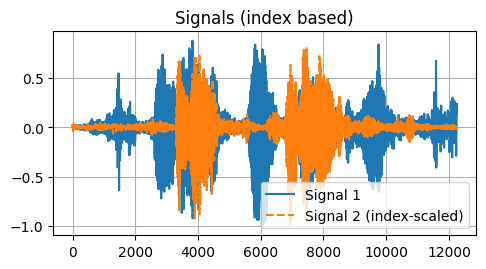

In [27]:
# ---------- Plot results ----------
plt.figure(figsize=(12,9))
# Top-left: signals (index scaled for visualization)
ax1 = plt.subplot2grid((3,2),(0,0))
ax1.plot(x, label="Signal 1", color='tab:blue')
ax1.plot(np.linspace(0, len(x)-1, len(y)), y, label="Signal 2 (index-scaled)", color='tab:orange', linestyle='--')
ax1.set_title("Signals (index based)")
ax1.legend(); ax1.grid(True)


The two audio signals of “HELLO , HOW ARE YOU?” did not match in timing because each speaker pronounced the word differently.

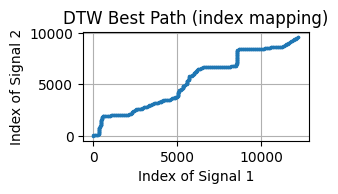

In [28]:
# Top-right: best path scatter
ax2 = plt.subplot2grid((3,2),(0,1))
bp_arr = np.array(best_path)
ax2.plot(bp_arr[:,0], bp_arr[:,1], '.', markersize=3)
ax2.set_title("DTW Best Path (index mapping)")
ax2.set_xlabel("Index of Signal 1")
ax2.set_ylabel("Index of Signal 2")
ax2.grid(True)

This plot shows how Dynamic Time Warping matches each point in Signal 1 to the closest similar point in Signal 2.

The x-axis shows the position (index) in Signal 1

The y-axis shows the matching position (index) in Signal 2

Each blue point is a match that DTW found between the two signals

What the shape tells us

The best path moves upward and to the right, which means both signals progress forward in time normally.

But the line is not a perfect diagonal.
This shows that the two “hello” recordings were spoken at different speeds.

Flat parts (horizontal stretches)
→ Signal 1 stayed in one region while Signal 2 moved faster
→ One person said that part more quickly

Steep parts (vertical stretches)
→ Signal 2 stayed in one region while Signal 1 moved ahead
→ One person stretched that part longer

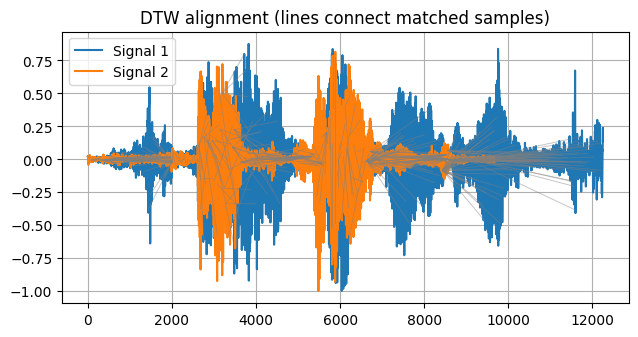

Saved plot -> dtw_upload_outputs/dtw_alignment_plot.png

Done. All outputs in folder: dtw_upload_outputs


In [29]:
# Bottom: alignment lines
ax3 = plt.subplot2grid((3,1),(1,0), rowspan=2)
ax3.plot(x, label="Signal 1", color='tab:blue')
ax3.plot(y, label="Signal 2", color='tab:orange')
max_lines = 600
step = max(1, len(best_path)//max_lines)
for k in range(0, len(best_path), step):
    i,j = best_path[k]
    if i < len(x) and j < len(y):
        ax3.plot([i, j], [x[i], y[j]], color='grey', alpha=0.45, linewidth=0.7)
ax3.set_title("DTW alignment (lines connect matched samples)")
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plot_path = os.path.join(OUTDIR, "dtw_alignment_plot.png")
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print("Saved plot ->", plot_path)

print("\nDone. All outputs in folder:", OUTDIR)

This plot shows how Dynamic Time Warping aligns the two audio signals (“hello” spoken by two different people).

The blue waveform = your voice

The orange waveform = your friend’s voice

The grey lines show which parts of both signals are matched by DTW

What the grey lines mean

Each grey line connects a point in Signal 1 to the most similar point in Signal 2.

Because both people said “hello” differently:

One may speak faster

One may stretch certain sounds (“he–llo”)

One may have a longer pause

Loudness and pitch may differ

DTW fixes these timing differences by stretching or compressing the time axis so that similar sound shapes match.

This plot proves that DTW is aligning similar spoken patterns even when:

one person speaks faster/slower

parts of the word are elongated

timing is different

It visually shows how DTW “warps time” so that both “hello” recordings match each other.